# Backpropagation & computational graphs — a step-by-step, runnable notebook

To train a network you need the gradient of the loss with respect to **every** weight. The naive way — nudge each weight and watch the loss — costs one forward pass *per weight*, hopeless for millions of parameters. **Backpropagation** computes *all* of them in a single backward pass, at about the cost of one extra forward pass. It is **reverse-mode automatic differentiation** on a computational graph: a forward pass caches values, then a backward pass sends *upstream gradient × local gradient* to each node, in reverse order.

This notebook builds that from scratch in NumPy and proves it correct **three independent ways** on real data: (1) against hand calculus (four worked examples, each checked against PyTorch autograd to ~1e-16); (2) against a numerical finite-difference gradient for every parameter (the from-scratch correctness proof); and (3) against PyTorch autograd, after which the from-scratch net is *trained* on scikit-learn digits to 97.8% test accuracy. Every cell uses the **exact same functions** as the chapter and its figures (imported from `backpropagation.py`), so the numbers here are the numbers there.

> Companion page: **Backpropagation & Computational Graphs**. Run top-to-bottom (Kernel → Restart & Run All); it is CPU-only, seeded, and finishes in a few seconds.

## Step 0 — Setup: import the real module and print versions

We import the from-scratch functions from the chapter module so this notebook runs the *same code* the page and figures use, and print the library versions the results were produced on.

In [1]:
import numpy as np
import torch
import sklearn

from backpropagation import (
    worked_scalar_graph, worked_sigmoid_neuron, worked_softmax_ce, worked_two_layer_net,
    MLP, softmax, gradient_check, epsilon_sweep, torch_cross_check, train_digits,
    depth_gradient_profile, load_digits_split,
)

np.random.seed(0)
torch.manual_seed(0)
print(f'numpy {np.__version__} | torch {torch.__version__} | scikit-learn {sklearn.__version__}  (CPU)')

numpy 2.4.6 | torch 2.12.0 | scikit-learn 1.9.0  (CPU)


## Step 1 — A scalar computational graph: $f = (a+b)\cdot c$

The whole algorithm in miniature. **Forward:** compute $s=a+b$, then $f=s\cdot c$, caching $s$ and $c$. **Backward:** seed $\partial f/\partial f = 1$, then push it back through each op using its *local* gradient — the multiply gate swaps its inputs ($\partial(sc)/\partial s = c$), the add gate distributes unchanged. With $a=2,b=1,c=3$ every gradient is $3$ (check: $f=ac+bc$, so $\partial f/\partial a=c=3$). We confirm against autograd.

In [2]:
g = worked_scalar_graph(a=2.0, b=1.0, c=3.0)
print(f'f = {g.f:.0f}')
print(f'gradients  dL/da, dL/db, dL/dc = {g.grads}')
print(f'max |hand - autograd| = {g.max_abs_diff_vs_torch:.1e}   (exact)')

f = 9
gradients  dL/da, dL/db, dL/dc = {'a': 3.0, 'b': 3.0, 'c': 3.0}
max |hand - autograd| = 0.0e+00   (exact)


## Step 2 — The four local-gradient gates, on numbers

Almost every backward pass is built from four routing patterns. With an upstream gradient of $2$:

- **add = distributor:** copies $2$ to *both* inputs (bias adds, residuals — gradient passes through).
- **multiply = swapper:** each input's gradient is $2\times$ *the other* input.
- **max / ReLU = router:** the whole $2$ goes to the winner, $0$ to the loser (the dead-ReLU effect).
- **copy / fan-out = adder:** a value used in several places gets the **sum** of the returning gradients (this is why `.grad` accumulates and why you call `zero_grad()`).

The fan-out sum is the rule beginners drop: $f = x\cdot x = x^2$ at $x=3$ sends back $3$ along each of the two edges, and the total is $3+3=6 = 2x$ — the factor of 2 in $2x$ *is* the two edges summing.

In [3]:
up = 2.0
x_, y_ = 3.0, 4.0
print(f'add       x<-{up:.0f}, y<-{up:.0f}         (distributes unchanged)')
print(f'multiply  x<-{up*y_:.0f}, y<-{up*x_:.0f}         (swaps: up*other input)')
print(f'max(5,1)  winner<-{up:.0f}, loser<-0     (routes to the larger input)')
x = 3.0
grad_fanout = up_edge = x + x   # both multiply edges send back the *other* x = 3
print(f'copy      f=x*x at x=3: grad = 3 + 3 = {grad_fanout:.0f} = 2x   (fan-out sums)')

add       x<-2, y<-2         (distributes unchanged)
multiply  x<-8, y<-6         (swaps: up*other input)
max(5,1)  winner<-2, loser<-0     (routes to the larger input)
copy      f=x*x at x=3: grad = 3 + 3 = 6 = 2x   (fan-out sums)


## Step 3 — A sigmoid neuron, end to end

One real neuron: $z = wx+b$, $a=\sigma(z)$, squared-error loss $L=\tfrac12(a-y)^2$, with $x=2,w=-1,b=3,y=0$. Backward, one factor at a time: $\partial L/\partial a = a-y$; through the sigmoid, $\partial a/\partial z = a(1-a)$; then through $z=wx+b$. Note $a(1-a)\le 0.25$: every sigmoid a gradient passes shrinks it by at least $4\times$ — the seed of vanishing gradients (Step 13).

In [4]:
s = worked_sigmoid_neuron(x=2.0, w=-1.0, b=3.0, y=0.0)
print(f'forward :  z = {s.z:.0f},  a = sigma(z) = {s.a:.4f},  L = {s.loss:.4f}')
print(f'backward:  dL/dw = {s.dL_dw:.4f},  dL/db = {s.dL_db:.4f},  dL/dx = {s.dL_dx:.4f}')
print(f'max |hand - autograd| = {s.max_abs_diff_vs_torch:.1e}')

forward :  z = 1,  a = sigma(z) = 0.7311,  L = 0.2672
backward:  dL/dw = 0.2875,  dL/db = 0.1437,  dL/dx = -0.1437
max |hand - autograd| = 4.2e-09


## Step 4 — Softmax + cross-entropy → $\hat y - y$

The classifier head has the most elegant gradient in deep learning. With logits $z$, softmax probabilities $p$, one-hot target $y$, and $L=-\log p_t$, the softmax Jacobian $\partial p_i/\partial z_j = p_i(\delta_{ij}-p_j)$ and the $-1/p_t$ from cross-entropy **cancel**, leaving simply

$$\frac{\partial L}{\partial z} = p - y.$$

Predicted probabilities minus the one-hot target — *exactly how wrong each class is*. The correct class gets a negative gradient (push its logit up); the wrong classes get positive gradients (push theirs down). Frameworks fuse the two ops for this clean gradient and for log-sum-exp stability.

In [5]:
sc = worked_softmax_ce(logits=(2.0, 1.0, 0.1), true_class=0)
print(f'softmax p       = {np.round(sc.p, 4)}')
print(f'dL/dz = p - y   = {np.round(sc.grad, 4)}   (class 0 negative, others positive)')
print(f'max |hand - autograd| = {sc.max_abs_diff_vs_torch:.1e}')

softmax p       = [0.659  0.2424 0.0986]
dL/dz = p - y   = [-0.341   0.2424  0.0986]   (class 0 negative, others positive)
max |hand - autograd| = 2.8e-17


## Step 5 — A full 2→2→2 net, forward AND backward by hand

The centrepiece: input $x\in\mathbb{R}^2$, a tanh hidden layer, a linear output layer, softmax + cross-entropy. Row-vector convention $z = xW+b$, so the matmul VJP reads $\partial L/\partial a_{\text{prev}} = W\delta$ and $\partial L/\partial W = x^\top\delta$. The four backprop equations, on real numbers: $\delta^2 = p-y$; $\partial L/\partial W^2 = (a^1)^\top\delta^2$; pull back $\partial L/\partial a^1 = W^2\delta^2$; through tanh $\delta^1 = \partial L/\partial a^1 \odot (1-(a^1)^2)$; then $\partial L/\partial W^1 = x^\top\delta^1$. Every number matches autograd to machine precision — this figure's annotations are these exact values.

In [6]:
net = worked_two_layer_net()
print('FORWARD')
print(f'  z1 = {np.round(net.z1,4)}   a1 = tanh(z1) = {np.round(net.a1,4)}')
print(f'  z2 = {np.round(net.z2,4)}   p = softmax(z2) = {np.round(net.p,4)}   L = {net.loss:.4f}')
print('BACKWARD')
print(f'  delta2 = p - y = {np.round(net.delta2,4)}')
print(f'  dL/dW2 =\n{np.round(net.dW2,4)}')
print(f'  dL/da1 = W2.delta2 = {np.round(net.da1,4)}   delta1 = {np.round(net.delta1,4)}')
print(f'  dL/dW1 =\n{np.round(net.dW1,4)}')
print(f'max |hand - autograd| over ALL gradients = {net.max_abs_diff_vs_torch:.1e}  (machine precision)')

FORWARD
  z1 = [0.6 1.3]   a1 = tanh(z1) = [0.537  0.8617]
  z2 = [0.5409 0.5122]   p = softmax(z2) = [0.5072 0.4928]   L = 0.6789
BACKWARD
  delta2 = p - y = [-0.4928  0.4928]
  dL/dW2 =
[[-0.2647  0.2647]
 [-0.4247  0.4247]]
  dL/da1 = W2.delta2 = [-0.1971  0.0493]   delta1 = [-0.1403  0.0127]
  dL/dW1 =
[[-0.1403  0.0127]
 [-0.2806  0.0254]]
max |hand - autograd| over ALL gradients = 1.1e-16  (machine precision)


## Step 6 — A from-scratch MLP: the forward pass, caching activations

Now scale up to a real network. `MLP` stores `(W, b)` per layer (row convention $Z = X @ W + b$), applies the hidden activation, and leaves the output layer linear (the loss is softmax + cross-entropy). The forward pass **caches** every pre-activation $z$ and activation $a$ — the backward pass needs them. Here is a 64→32→10 net on a batch of real digit images.

In [7]:
x_tr, x_te, y_tr, y_te = load_digits_split()
mlp = MLP([64, 32, 10], activation='relu', seed=0)
logits, cache = mlp.forward(x_tr[:8])
print(f'input batch      : {x_tr[:8].shape}   (8 flattened 8x8 digit images)')
print(f'cached tensors   : {sorted(cache.keys())}')
print(f'logits shape     : {logits.shape}   softmax row 0 sums to {softmax(logits)[0].sum():.4f}')

input batch      : (8, 64)   (8 flattened 8x8 digit images)
cached tensors   : ['a-1', 'a0', 'a1', 'z0', 'z1']
logits shape     : (8, 10)   softmax row 0 sums to 1.0000


## Step 7 — The backward pass: the four equations, in code

This is the entire algorithm. Seed the output error $\delta = (p-y)/N$ (mean reduction over the batch), then for each layer from the output down: read off $\partial L/\partial W = a_{\text{prev}}^\top\delta$ and $\partial L/\partial b = \sum_{\text{batch}}\delta$, then pull the error back one layer with $W^\top\delta$ and multiply by the activation's local gradient. The gradient shapes must match the parameter shapes — that is how a missing transpose is caught.

In [8]:
y_onehot = np.eye(10)[y_tr[:8]]
grads = mlp.backward(cache, y_onehot)
for name in ['W0', 'b0', 'W1', 'b1']:
    assert grads[name].shape == mlp.params[name].shape
    print(f'  grad {name}: shape {grads[name].shape} == param shape  (norm {np.linalg.norm(grads[name]):.4f})')

  grad W0: shape (64, 32) == param shape  (norm 3.9878)
  grad b0: shape (32,) == param shape  (norm 0.5770)
  grad W1: shape (32, 10) == param shape  (norm 3.6147)
  grad b1: shape (10,) == param shape  (norm 0.4982)


## Step 8 — Gradient check: analytic backward vs numerical finite difference

The from-scratch correctness proof. For **every** parameter, compare the analytic backprop gradient to a **centred finite difference** $\big(L(\theta+\epsilon)-L(\theta-\epsilon)\big)/2\epsilon$ using the robust *relative* error. On float64 the median relative error is ~1e-10 and the max ~1e-7 (a few small-gradient parameters inflate the ratio) — both far below the ~1e-3 that would flag a bug. This is an *independent* algorithm agreeing with backprop, so it rules out a shared mistake.

In [9]:
check_net = MLP([64, 16, 10], activation='tanh', seed=0)
gc = gradient_check(check_net, x_tr[:16], np.eye(10)[y_tr[:16]], eps=1e-5)
print(f'parameters checked    : {gc.n_params}')
print(f'median relative error : {gc.median_rel_error:.2e}')
print(f'max    relative error : {gc.max_rel_error:.2e}   (<< 1e-3 => backward pass is correct)')
# hard gate: a broken backward pass must FAIL here, not just print a bad number
assert gc.max_rel_error < 1e-3, f'gradient check failed: max rel error {gc.max_rel_error:.2e}'
print('OK: gradient check confirms the from-scratch backward pass')

parameters checked    : 1210
median relative error : 1.65e-10
max    relative error : 7.74e-08   (<< 1e-3 => backward pass is correct)
OK: gradient check confirms the from-scratch backward pass


## Step 9 — The ε U-curve: why the step size matters

The finite-difference error is a **U** in $\epsilon$. Too *large* an $\epsilon$ leaves $O(\epsilon^2)$ **truncation error** (the difference isn't the true derivative); too *small* an $\epsilon$ subtracts two nearly-equal floats and amplifies floating-point **round-off**. The sweet spot for float64 sits near $\epsilon\approx 10^{-6}$. On $f(w)=\tfrac12(\tanh 3w - 0.5)^2$ at $w=0.7$ (analytic derivative $0.082173$):

In [10]:
analytic, pts = epsilon_sweep(w=0.7)
print(f'analytic derivative = {analytic:.6f}\n')
print(f"{'eps':>8}{'numerical':>14}{'rel error':>14}")
for p in pts:
    print(f'  {p.eps:>8.0e}{p.numerical:>14.6f}{p.rel_error:>12.2e}')

analytic derivative = 0.082173

     eps     numerical     rel error
     1e-01      0.085764    2.14e-02
     1e-02      0.082210    2.20e-04
     1e-03      0.082174    2.20e-06
     1e-04      0.082173    2.20e-08
     1e-05      0.082173    2.17e-10
     1e-06      0.082173    3.95e-11
     1e-07      0.082173    8.42e-10
     1e-08      0.082173    1.06e-08
     1e-10      0.082173    6.54e-08


## Step 10 — Cross-check against a real autodiff engine (PyTorch)

Rebuild the exact from-scratch net in PyTorch, call `loss.backward()`, and compare gradients. They agree to machine epsilon — because autograd runs the *same* chain-rule VJPs we coded by hand. This is the 'matches the real engine' proof.

In [11]:
tm = torch_cross_check(check_net, x_tr[:16], y_tr[:16])
print(f'max |from-scratch - autograd| = {tm.max_abs_diff:.2e}')
print(f'allclose(atol=1e-10)          = {tm.all_close}')
# hard gate: the from-scratch gradients must match the reference autodiff engine
assert tm.all_close, f'torch cross-check failed: max abs diff {tm.max_abs_diff:.2e}'
print('OK: from-scratch gradients match PyTorch autograd')

max |from-scratch - autograd| = 8.33e-17
allclose(atol=1e-10)          = True
OK: from-scratch gradients match PyTorch autograd


## Step 11 — Put backprop to work: train on scikit-learn digits

The payoff. Feed the from-scratch gradients to plain mini-batch **SGD** (no autograd, no framework) and train a 64→64→10 ReLU network on 1,347 handwritten digits. The cross-entropy loss falls from ~2.8 toward zero and the held-out **test accuracy** climbs past 96% — proof the gradients are not just numerically correct but *useful*: they point downhill. Backprop computes the gradient; SGD (the optimizer) uses it.

In [12]:
tr = train_digits(hidden=64, epochs=60, batch_size=64, lr=0.2)
print(f'net = 64 -> 64 -> 10 ReLU, {tr.n_params} params; {tr.n_train} train / {tr.n_test} test')
print(f'loss: {tr.loss_history[0]:.3f} -> {tr.loss_history[-1]:.3f} over {tr.epochs} epochs')
print(f'train accuracy = {tr.train_acc:.4f}   test accuracy = {tr.test_acc:.4f}')

net = 64 -> 64 -> 10 ReLU, 4810 params; 1347 train / 450 test
loss: 2.796 -> 0.005 over 60 epochs
train accuracy = 1.0000   test accuracy = 0.9778


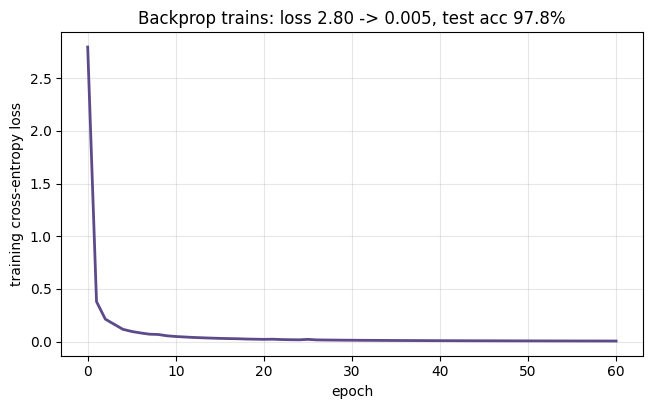

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(tr.loss_history, color='#5D4A8A', lw=2)
ax.set_xlabel('epoch')
ax.set_ylabel('training cross-entropy loss')
ax.set_title(f'Backprop trains: loss {tr.loss_history[0]:.2f} -> {tr.loss_history[-1]:.3f}, test acc {tr.test_acc*100:.1f}%')
ax.grid(True, alpha=0.3)
plt.show()

## Step 12 — The vanishing product, measured across depth

The backward error recurrence $\delta^l = ((W^{l+1})^\top\delta^{l+1})\odot\sigma'(z^l)$ multiplies $\sim D$ factors as it flows toward the input. If those factors are consistently below one — sigmoid's $\sigma'\le 0.25$ — the gradient **vanishes** geometrically toward the early layers. We pull one backward pass through a 12-layer net and read the per-layer weight-gradient norm: sigmoid's is orders of magnitude smaller at layer 1 than at the output, while ReLU (local gradient exactly 1 in its active region) stays flat. This one product motivates ReLU, residual connections, normalization, and careful initialization.

In [14]:
for kind in ('sigmoid', 'relu'):
    prof = depth_gradient_profile(depth=12, activation=kind)
    ratio = prof.grad_norms[0] / prof.grad_norms[-1]
    print(f'{kind:<8}: ||dW|| layer 1 = {prof.grad_norms[0]:.2e},  layer L = {prof.grad_norms[-1]:.2e}'
          f'   (layer 1 is {ratio:.0e}x the output layer)')

sigmoid : ||dW|| layer 1 = 2.98e-09,  layer L = 6.71e-01   (layer 1 is 4e-09x the output layer)
relu    : ||dW|| layer 1 = 4.28e-04,  layer L = 3.85e-04   (layer 1 is 1e+00x the output layer)


## Recap

Backprop is **reverse-mode autodiff on the computational graph**: a forward pass caches values, then a backward pass sends *upstream × local gradient* to each node in reverse order, **summing** at fan-outs. It is the chain rule plus **dynamic programming** — each $\delta$ computed once and reused — so *all* gradients come out in one pass, because the loss is a single scalar (many inputs, one output → reverse mode wins). The softmax+CE gradient is $p-y$; the matmul gradients are $\delta x^\top$ and $W^\top\delta$. We proved the from-scratch backward pass correct against hand calculus (~1e-16), a numerical gradient (median rel error ~1e-10), and PyTorch autograd, then trained a network with it to 97.8% test accuracy. Backprop computes the gradient; the **optimizer** does the update.

See the companion page for the full derivations, pitfalls, and references.